In [1]:
# Mount google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Path of directory
drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/dataset/"

In [3]:
import pandas as pd

In [4]:
# Load data
df_mx_solvent_data_labeled = pd.read_pickle(f"{root_path}/dataset_mx_solvent_polarity.pkl")
df_mx_solvent_data_labeled.columns = df_mx_solvent_data_labeled.columns.str.lower()
print(df_mx_solvent_data_labeled.shape)
df_mx_solvent_data_labeled.head()

(660, 65)


,mx,label,inchikey,gap_oh,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [5]:
cols_to_keep = [col for col in df_mx_solvent_data_labeled.columns if not (df_mx_solvent_data_labeled[col].nunique() <= 1)]
df_mx_solvent_data_labeled = df_mx_solvent_data_labeled[cols_to_keep]

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [7]:
df_mx_solvent_data_labeled['method_hf'] = df_mx_solvent_data_labeled['method_hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_licl/hf'] = df_mx_solvent_data_labeled['method_licl/hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_lif/hcl'] = df_mx_solvent_data_labeled['method_lif/hcl'].astype('category').cat.codes

In [8]:
df_mx_solvent_data_labeled.head()

,mx,label,inchikey,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,atom_stereo_count,boiling_point,solvent,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,1,0,373.2,oxidane,1,0,0
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,3,0,351.5,ethanol,1,0,0
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,2,0,337.8,methanol,1,0,0
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,4,0,329.3,propan-2-one,1,0,0
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,3,0,354.8,acetonitrile,1,0,0


In [9]:
df_mx_solvent_data_labeled.columns

Index(['mx', 'label', 'inchikey', 'work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'p', 'x_e', 'x_d', 'x_n',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point', 'solvent', 'method_hf',
       'method_licl/hf', 'method_lif/hcl'],
      dtype='object')

In [10]:
features = ['work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'p', 'x_e', 'x_d', 'x_n',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point', 'method_hf',
       'method_licl/hf', 'method_lif/hcl']
X = df_mx_solvent_data_labeled[features]
y = df_mx_solvent_data_labeled['label']

In [11]:
X.head()

,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,plasmafrequency_y_oh,has_inversion_symmetry_oh,gap_o,...,complexity,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,atom_stereo_count,boiling_point,method_hf,method_licl/hf,method_lif/hcl
0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,0.0,1,1,0,1,0,373.2,1,0,0
1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2.8,1,1,0,3,0,351.5,1,0,0
2,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2.0,1,1,0,2,0,337.8,1,0,0
3,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,26.3,0,1,0,4,0,329.3,1,0,0
4,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,29.3,0,1,0,3,0,354.8,1,0,0


In [12]:
y.head()

,label
0,1
1,1
2,-1
3,-1
4,-1


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
mask_pos = y == 1
mask_neg = y == -1
mask_unlabeled = y == 0


In [15]:
X_train = X[mask_pos | mask_neg]
y_train = y[mask_pos | mask_neg]

In [16]:
X_test = X[mask_unlabeled]
df_unlabeled = df_mx_solvent_data_labeled[mask_unlabeled].copy()

In [17]:
X_train_train, X_val, y_train_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [18]:
print(len(X_train_train))
print(len(X_val))
print(len(y_train_train))
print(len(y_val))

51
13
51
13


In [19]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint, uniform
import xgboost as xgb

In [20]:
param_dist = {
    'estimator__max_depth': randint(3, 10),
    'estimator__learning_rate': uniform(0.01, 0.3),
    'estimator__n_estimators': randint(50, 200),
    'estimator__subsample': uniform(0.6, 0.4),
    'estimator__colsample_bytree': uniform(0.6, 0.4)
}

In [21]:
base_rf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)
bagging_clf = BaggingClassifier(estimator=base_rf, n_estimators=10, random_state=42)

In [22]:
rand_search = RandomizedSearchCV(
    estimator=bagging_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)
rand_search.fit(X_train_train, y_train_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__max_depth=5, estimator__n_estimators=121, estimator__subsample=0.8394633936788146; total time=   0.3s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__max_depth=5, estimator__n_estimators=121, estimator__subsample=0.8394633936788146; total time=   0.2s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__max_depth=5, estimator__n_estimators=121, estimator__subsample=0.8394633936788146; total time=   0.3s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0.2952142919229748, estimator__max_depth=5, estimator__n_estimators=121, estimator__subsample=0.8394633936788146; total time=   0.2s
[CV] END estimator__colsample_bytree=0.749816047538945, estimator__learning_rate=0

RandomizedSearchCV(cv=5,
                   estimator=BaggingClassifier(estimator=XGBClassifier(base_score=None,
                                                                       booster=None,
                                                                       callbacks=None,
                                                                       colsample_bylevel=None,
                                                                       colsample_bynode=None,
                                                                       colsample_bytree=None,
                                                                       device=None,
                                                                       early_stopping_rounds=None,
                                                                       enable_categorical=False,
                                                                       eval_metric='logloss',
                                                                       feature_types=None,
                                                                       feature_weights=None,
                                                                       gamma=None,
                                                                       grow_policy=None,
                                                                       importanc...
                                        'estimator__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c57b5a3e120>,
                                        'estimator__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c57b5a35c40>,
                                        'estimator__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c57b59d0f20>},
                   random_state=42, scoring='accuracy', verbose=2)

In [23]:
best_model = rand_search.best_estimator_
print(best_model)

BaggingClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=np.float64(0.749816047538945),
                                          device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='logloss',
                                          feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=

In [24]:
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Report:\n", classification_report(y_val, y_val_pred))

Train Accuracy: 0.9375
Val Accuracy: 0.8461538461538461
Validation Report:
               precision    recall  f1-score   support

          -1       0.80      0.80      0.80         5
           1       0.88      0.88      0.88         8

    accuracy                           0.85        13
   macro avg       0.84      0.84      0.84        13
weighted avg       0.85      0.85      0.85        13



In [25]:
proba_unlabeled = best_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (positive)
df_unlabeled['predicted_proba'] = proba_unlabeled
df_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

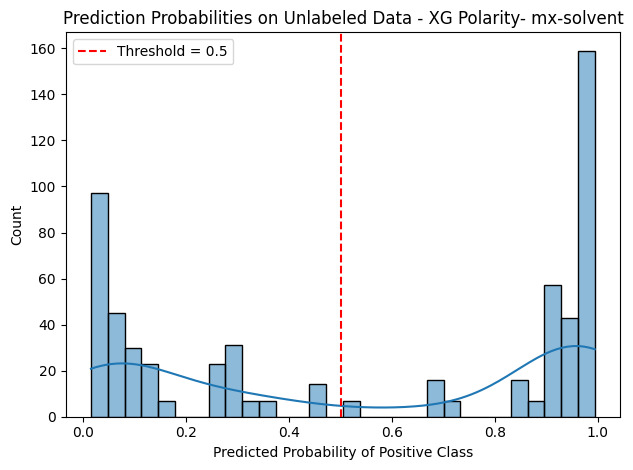

In [27]:
sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - XG Polarity- mx-solvent")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
high_conf = df_unlabeled[df_unlabeled['predicted_proba'] >= 0.9]
top_10 = high_conf.sort_values(by='predicted_proba', ascending=False).head(20)
print(top_10[['solvent', 'mx', 'predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

                      solvent     mx  predicted_proba  method_lif/hcl  \
613  1-methylpyrrolidin-2-one  Ta4C3         0.993960               1   
533  1-methylpyrrolidin-2-one   V4C3         0.993960               1   
373  1-methylpyrrolidin-2-one  Ti2C1         0.993960               1   
453  1-methylpyrrolidin-2-one  Zr3C2         0.993960               1   
293  1-methylpyrrolidin-2-one  Mo2C1         0.993960               1   
161  1-methylpyrrolidin-2-one  Nb2C1         0.991900               0   
240  1-methylpyrrolidin-2-one   V2C1         0.991900               0   
347  1-methylpyrrolidin-2-one  Ti2C1         0.991900               0   
640  1-methylpyrrolidin-2-one  Ta4C3         0.991900               0   
426  1-methylpyrrolidin-2-one  Zr3C2         0.991900               0   
320  1-methylpyrrolidin-2-one  Mo2C1         0.991900               0   
266  1-methylpyrrolidin-2-one  Mo2C1         0.991900               0   
480  1-methylpyrrolidin-2-one  Zr3C2         0.9919

In [29]:
low_conf = df_unlabeled[df_unlabeled['predicted_proba'] <= 0.1]
bottom_10 = low_conf.sort_values(by='predicted_proba', ascending=True).head(20)

print("MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):")
print(bottom_10[['mx', 'solvent','predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):
        mx          solvent  predicted_proba  method_lif/hcl  method_licl/hf  \
71   Ti3C2  dichloromethane         0.014924               0               0   
118  Nb2C1  dichloromethane         0.014924               0               0   
276  Mo2C1  dichloromethane         0.014924               0               0   
197   V2C1  dichloromethane         0.014924               0               0   
436  Zr3C2  dichloromethane         0.014924               0               0   
357  Ti2C1  dichloromethane         0.014924               0               0   
596  Ta4C3  dichloromethane         0.014924               0               0   
516   V4C3  dichloromethane         0.014924               0               0   
330  Mo2C1  dichloromethane         0.015431               0               1   
410  Ti2C1  dichloromethane         0.015431               0               1   
171  Nb2C1  dichloromethane         0.015431               0

In [30]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(df_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

df_unlabeled['confidence_bin'] = pd.cut(df_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(df_unlabeled['confidence_bin'].value_counts().sort_index())


=== Summary of predicted probabilities on unlabeled data ===
count    596.000000
mean       0.550444
std        0.410979
min        0.014924
25%        0.082164
50%        0.674524
75%        0.963421
max        0.993960
Name: predicted_proba, dtype: float64

=== Prediction count by confidence bin ===
confidence_bin
Very Low (≤0.1)          172
Low (0.1–0.3)             76
Mid (0.3–0.5)             36
High (0.5–0.7)            23
Very High (0.7–0.9)       30
Extremely High (>0.9)    259
Name: count, dtype: int64


In [31]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/final/polarity/"

In [32]:
df_unlabeled.to_csv(f"{train_path}/005_p_vs_n_predictions_unlabeled_polarity-xg-normalize-fintune-mxsolv.csv")
df_unlabeled.to_pickle(f"{train_path}/005_p_vs_n_predictions_unlabeled_polarity-xg-normalize-fintune-mxsolv.pkl")


                      feature  importance
31                        x_n    0.194238
41              boiling_point    0.189428
33                      xlogp    0.183397
36         h_bond_donor_count    0.120685
34                       tpsa    0.095181
29                        x_e    0.067080
30                        x_d    0.046393
28                          p    0.044788
32           molecular_weight    0.025475
44             method_lif/hcl    0.012676
42                  method_hf    0.011667
39           heavy_atom_count    0.004513
35                 complexity    0.004478
12                    ehull_o    0.000000
11         formation_energy_o    0.000000
10            work_function_o    0.000000
9                       gap_o    0.000000
8   has_inversion_symmetry_oh    0.000000
7        plasmafrequency_y_oh    0.000000
6        plasmafrequency_x_oh    0.000000
5                alphaz_el_oh    0.000000
4                alphay_el_oh    0.000000
3                alphax_el_oh    0

/tmp/ipython-input-2797592131.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')


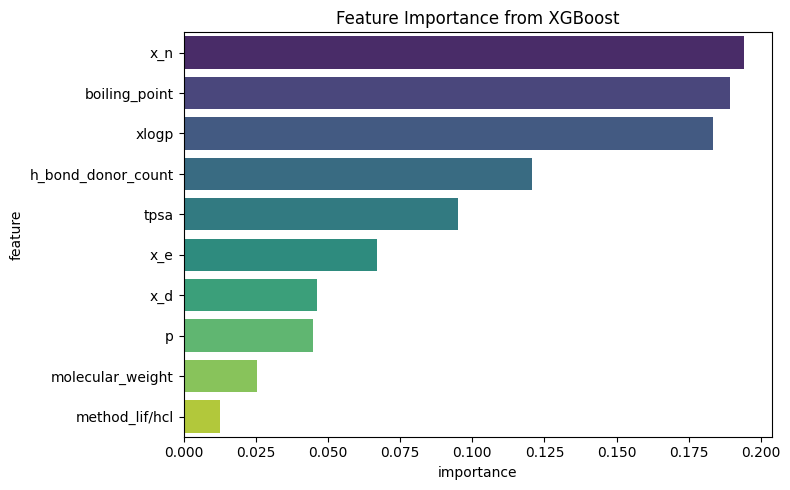

In [33]:
feature_names = X.columns

# Later, after training
importances = np.array([tree.feature_importances_ for tree in best_model.estimators_])
mean_importance = np.mean(importances, axis=0)

# Use saved feature_names directly
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Feature Importance from XGBoost')
plt.tight_layout()
plt.show()

In [34]:
mx_features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f']
solv_features = ['p', 'x_e', 'x_d',
       'x_n', 'boiling_point', 'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count']
# add_features = ['molecular_weight_additive', 'xlogp_additive', 'tpsa_additive',
      #  'complexity_additive', 'h_bond_donor_count_additive',
      #  'h_bond_acceptor_count_additive', 'rotatable_bond_count_additive',
      #  'heavy_atom_count_additive', 'atom_stereo_count_additive',
      #  'bond_stereo_count_additive', 'covalent_unit_count_additive']



In [35]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# top_add = feature_importance_df[feature_importance_df['feature'].isin(add_features)] \
#               .sort_values(by='importance', ascending=False) \
#               .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

# print("\nTotal  Additive Features:", len(add_features))
# print("Top 5 Additive Features:")
# print(top_solv.to_string(index=False))

Total  MXene Features: 28
Top 5 MXene Features:
                  feature  importance
                  ehull_o         0.0
       formation_energy_o         0.0
          work_function_o         0.0
                    gap_o         0.0
has_inversion_symmetry_oh         0.0

Total  Solvent Features: 14
Top 5 Solvent Features:
           feature  importance
               x_n    0.194238
     boiling_point    0.189428
             xlogp    0.183397
h_bond_donor_count    0.120685
              tpsa    0.095181
